# # Farmer Meeting Feedback Analysis and Attendance Prediction Using Machine Learning

## Project Objective
The objective of this project is to analyze farmer meeting feedback, identify patterns in attendance and product responses, visualize survey insights, and predict farmer meeting attendance using Machine Learning algorithms.

## Algorithms Used
1. Binary Logistic Regression
2. Decision Tree Classifier
3. Confusion Matrix
4. Simple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("A_to_Z_Mega_Meeting_All_English_Analysis_ML.csv")

In [3]:
df

,Record_ID,Source_Row,Farmer_Name,Territory,Depot,Crop,Meeting_Location,Mobile_Number,Call_Status,Attendance_Response,...,Purchased_Product_List_Standardized,Purchased_Product_Count,Purchase_Stage_Score,Preference_Response_Status,Survey_Response_Status,Data_Quality_Flag,Territory_Barguna,Territory_Patuakhali,Territory_Charfashon,Territory_Kalapara
0,1,3,Md. Monir Molla,Kalapara,Barishal,Watermelon,Dakshin Debpur,01740810873,Successful,Yes,...,NaN,0.0,1.0,Unknown / cannot recall,Complete survey response,Valid record,0,0,0,1
1,2,4,Md. Hamim,Kalapara,Barishal,Watermelon,Dakshin Debpur,01736399686,Successful,NaN,...,NaN,NaN,NaN,Missing,No survey response,No survey response,0,0,0,1
2,3,5,Md. Harun Molla,Kalapara,Barishal,Watermelon,Dakshin Debpur,01745429530,Successful,Yes,...,Litosen,1.0,2.0,Named product(s),Complete survey response,Valid record,0,0,0,1
3,4,6,Md. Kamal Mia,Kalapara,Barishal,Watermelon,Dakshin Debpur,01759171520,Successful,NaN,...,NaN,NaN,NaN,Missing,No survey response,No survey response,0,0,0,1
4,5,7,Md. Amir Hossain,Kalapara,Barishal,Watermelon,Dakshin Debpur,01722165463,Successful,Yes,...,"Kurenox, Zinc, Boron",3.0,2.0,Named product(s),Complete survey response,Valid record,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,549,554,Md. Liton Salotija,Charfashon,Barishal,Watermelon,"Mujibnagar, Charfashon",N/G,N/G,NaN,...,NaN,NaN,NaN,Missing,No survey response,Not Given (N/G); No survey response,0,0,1,0
549,550,555,Abu Taher,Charfashon,Barishal,Watermelon,"Mujibnagar, Charfashon",01758395677,Someone Receive,NaN,...,NaN,NaN,NaN,Missing,No survey response,No survey response,0,0,1,0
550,551,556,Alamj,Charfashon,Barishal,Watermelon,"Mujibnagar, Charfashon",01791592677,Successful,Yes,...,NaN,0.0,2.0,Unknown / cannot recall,Complete survey response,Valid record,0,0,1,0
551,552,557,Iusuf,Charfashon,Barishal,Watermelon,"Mujibnagar, Charfashon",01798715082,Successful,Yes,...,NaN,0.0,2.0,Unknown / cannot recall,Complete survey response,Valid record,0,0,1,0


In [4]:
df.head()

,Record_ID,Source_Row,Farmer_Name,Territory,Depot,Crop,Meeting_Location,Mobile_Number,Call_Status,Attendance_Response,...,Purchased_Product_List_Standardized,Purchased_Product_Count,Purchase_Stage_Score,Preference_Response_Status,Survey_Response_Status,Data_Quality_Flag,Territory_Barguna,Territory_Patuakhali,Territory_Charfashon,Territory_Kalapara
0,1,3,Md. Monir Molla,Kalapara,Barishal,Watermelon,Dakshin Debpur,01740810873,Successful,Yes,...,NaN,0.0,1.0,Unknown / cannot recall,Complete survey response,Valid record,0,0,0,1
1,2,4,Md. Hamim,Kalapara,Barishal,Watermelon,Dakshin Debpur,01736399686,Successful,NaN,...,NaN,NaN,NaN,Missing,No survey response,No survey response,0,0,0,1
2,3,5,Md. Harun Molla,Kalapara,Barishal,Watermelon,Dakshin Debpur,01745429530,Successful,Yes,...,Litosen,1.0,2.0,Named product(s),Complete survey response,Valid record,0,0,0,1
3,4,6,Md. Kamal Mia,Kalapara,Barishal,Watermelon,Dakshin Debpur,01759171520,Successful,NaN,...,NaN,NaN,NaN,Missing,No survey response,No survey response,0,0,0,1
4,5,7,Md. Amir Hossain,Kalapara,Barishal,Watermelon,Dakshin Debpur,01722165463,Successful,Yes,...,"Kurenox, Zinc, Boron",3.0,2.0,Named product(s),Complete survey response,Valid record,0,0,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 33 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Record_ID                                 553 non-null    int64  
 1   Source_Row                                553 non-null    int64  
 2   Farmer_Name                               553 non-null    object 
 3   Territory                                 553 non-null    object 
 4   Depot                                     553 non-null    object 
 5   Crop                                      553 non-null    object 
 6   Meeting_Location                          553 non-null    object 
 7   Mobile_Number                             553 non-null    object 
 8   Call_Status                               553 non-null    object 
 9   Attendance_Response                       210 non-null    object 
 10  Preferred_Product_Response            

In [8]:
df.shape

(553, 33)

In [9]:
df.columns

Index(['Record_ID', 'Source_Row', 'Farmer_Name', 'Territory', 'Depot', 'Crop',
       'Meeting_Location', 'Mobile_Number', 'Call_Status',
       'Attendance_Response', 'Preferred_Product_Response',
       'Purchase_Response', 'Recommendation_Response',
       'Future_Meeting_Interest_Response',
       'Representative_Contact_Interest_Response', 'Comment',
       'Phone_Data_Status', 'Valid_Mobile_Flag', 'Call_Success_Flag',
       'Meeting_Attendance_Flag', 'Feedback_Response_Count',
       'Preferred_Product_List_Standardized', 'Preferred_Product_Count',
       'Purchased_Product_List_Standardized', 'Purchased_Product_Count',
       'Purchase_Stage_Score', 'Preference_Response_Status',
       'Survey_Response_Status', 'Data_Quality_Flag', 'Territory_Barguna',
       'Territory_Patuakhali', 'Territory_Charfashon', 'Territory_Kalapara'],
      dtype='object')

# Missing Value Check

In [10]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Comment                                     538
Purchased_Product_List_Standardized         460
Preferred_Product_List_Standardized         455
Purchase_Stage_Score                        413
Preferred_Product_Response                  402
Purchase_Response                           402
Preferred_Product_Count                     402
Purchased_Product_Count                     402
Recommendation_Response                     401
Future_Meeting_Interest_Response            401
Representative_Contact_Interest_Response    401
Attendance_Response                         343
Meeting_Attendance_Flag                     343
dtype: int64

#  Call Status Analysis

In [11]:
df["Call_Status"].value_counts()

Call_Status
Successful         218
Unreachable        154
N/G                 62
Someone Receive     30
Busy                30
Repeat              29
Switch off          20
Wrong Number        10
Name: count, dtype: int64

#  Territory-wise Farmer Count

In [12]:
df["Territory"].value_counts()

Territory
Barguna       178
Patuakhali    171
Charfashon    114
Kalapara       90
Name: count, dtype: int64

#  Crop-wise Farmer Count

In [13]:
df["Crop"].value_counts()

Crop
Watermelon    553
Name: count, dtype: int64

#  Meeting Attendance Analysis

In [14]:
df["Attendance_Response"].value_counts(dropna=False)

Attendance_Response
NaN    343
Yes    167
No      43
Name: count, dtype: int64

# Product Purchase Stage Analysis

In [15]:
df["Purchase_Stage_Score"].value_counts(dropna=False).sort_index()

Purchase_Stage_Score
0.0      6
1.0     33
2.0    101
NaN    413
Name: count, dtype: int64

# Feedback Response Count Analysis

In [16]:
df["Feedback_Response_Count"].value_counts().sort_index()

Feedback_Response_Count
0    343
1     58
4      1
6    151
Name: count, dtype: int64

# Valid Mobile Number Analysis

In [17]:
df["Phone_Data_Status"].value_counts()

Phone_Data_Status
Valid              486
Not Given (N/G)     61
Invalid format       6
Name: count, dtype: int64

# Outlier Detection

## Numerical Column Summary

In [18]:
numerical_columns = [
    "Feedback_Response_Count",
    "Preferred_Product_Count",
    "Purchased_Product_Count",
    "Purchase_Stage_Score"
]

df[numerical_columns].describe()

,Feedback_Response_Count,Preferred_Product_Count,Purchased_Product_Count,Purchase_Stage_Score
count,553.000000,151.000000,151.000000,140.000000
mean,1.750452,1.165563,1.013245,1.678571
std,2.629116,1.162930,1.070743,0.553184
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000
50%,0.000000,1.000000,1.000000,2.000000
75%,6.000000,2.000000,1.500000,2.000000
max,6.000000,4.000000,4.000000,2.000000


## IQR Method দিয়ে Outlier বের করা

In [19]:
Q1 = df["Purchased_Product_Count"].quantile(0.25)

Q3 = df["Purchased_Product_Count"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Purchased_Product_Count"] < lower_limit) |
    (df["Purchased_Product_Count"] > upper_limit)
]

outliers[
    [
        "Farmer_Name",
        "Territory",
        "Preferred_Product_Count",
        "Purchased_Product_Count",
        "Purchase_Response"
    ]
]

,Farmer_Name,Territory,Preferred_Product_Count,Purchased_Product_Count,Purchase_Response
325,Md. Jalal,Patuakhali,4.0,4.0,"Double, Pillarthen, Mansar, NAAFCO Boron"
346,Mojammel Pyada,Patuakhali,4.0,4.0,"Double, Pillarthen, Mansar, SOP"
348,Badol Pyada,Patuakhali,3.0,4.0,"Double, Pillarthen, Mansar, SOP"
423,Roni,Patuakhali,4.0,4.0,"Mansar, Litosen, Jampro, Tango"
445,Md. Iusuf Karigor,Charfashon,4.0,4.0,"Mansar, Boron, Zinc, Semcap"


# Preferred Product Count-এর IQR Outlier

In [20]:
Q1 = df["Preferred_Product_Count"].quantile(0.25)

Q3 = df["Preferred_Product_Count"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

preferred_outliers = df[
    (df["Preferred_Product_Count"] < lower_limit) |
    (df["Preferred_Product_Count"] > upper_limit)
]

preferred_outliers[
    [
        "Farmer_Name",
        "Territory",
        "Preferred_Product_Count",
        "Preferred_Product_Response"
    ]
]

,Farmer_Name,Territory,Preferred_Product_Count,Preferred_Product_Response


# Visualization

## Call Status Bar Chart

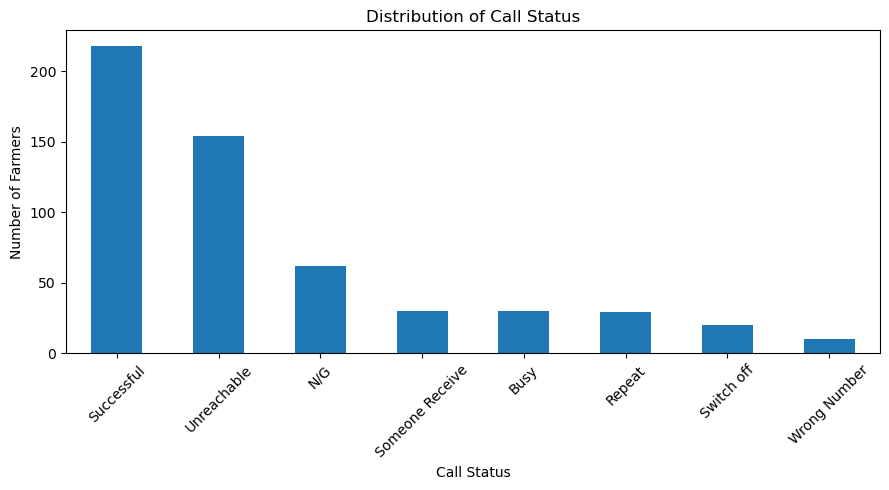

In [21]:
df["Call_Status"].value_counts().plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Distribution of Call Status")
plt.xlabel("Call Status")
plt.ylabel("Number of Farmers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Territory-wise Farmer Distribution

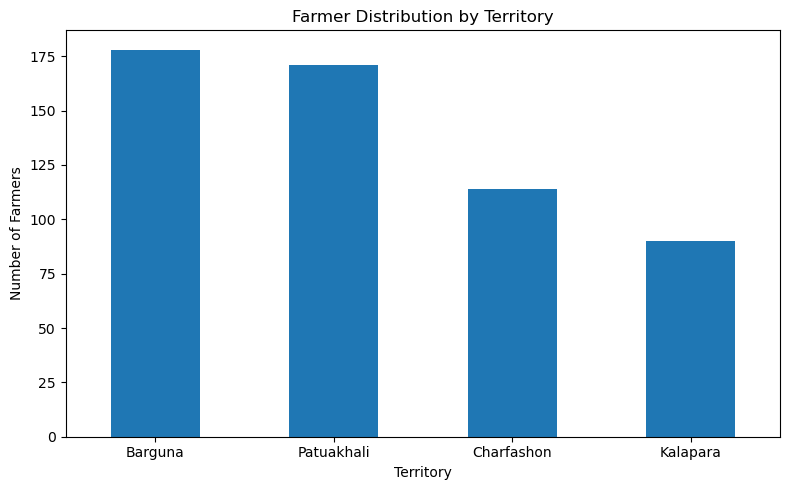

In [22]:
df["Territory"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Farmer Distribution by Territory")
plt.xlabel("Territory")
plt.ylabel("Number of Farmers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Meeting Attendance Pie Chart

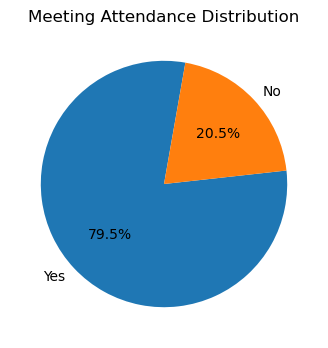

In [27]:
attendance_counts = df["Attendance_Response"].dropna().value_counts()

attendance_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=80,
    figsize=(4, 4)
)

plt.title("Meeting Attendance Distribution")
plt.ylabel("")
plt.show()

## Purchase Stage Bar Chart

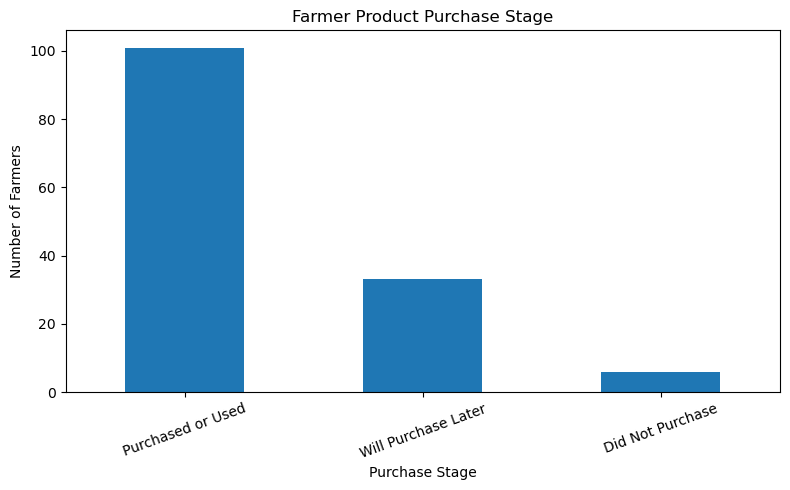

In [28]:
purchase_stage = df["Purchase_Stage_Score"].map({
    0: "Did Not Purchase",
    1: "Will Purchase Later",
    2: "Purchased or Used"
})

purchase_stage.value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Farmer Product Purchase Stage")
plt.xlabel("Purchase Stage")
plt.ylabel("Number of Farmers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Top Preferred Product Chart

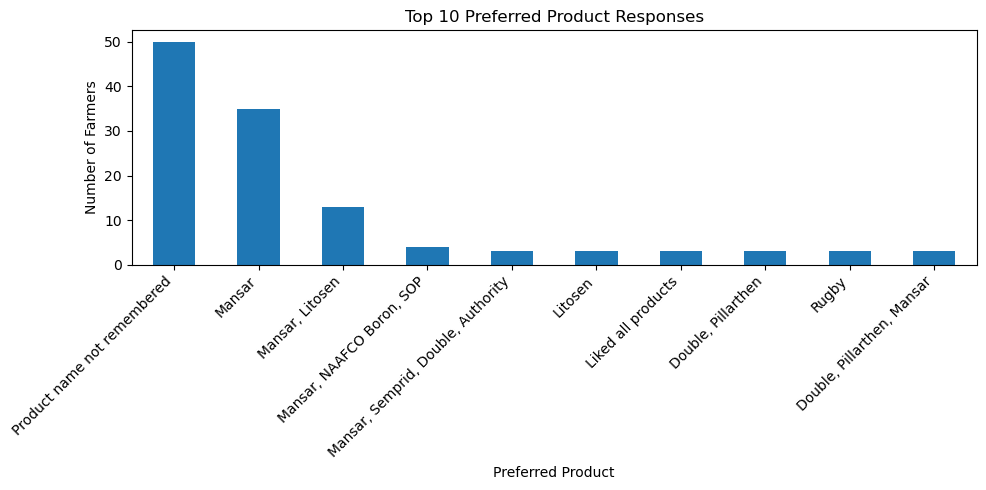

In [29]:
top_products = df["Preferred_Product_Response"].dropna().value_counts().head(10)

top_products.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Preferred Product Responses")
plt.xlabel("Preferred Product")
plt.ylabel("Number of Farmers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Preferred Product Count-এর Boxplot

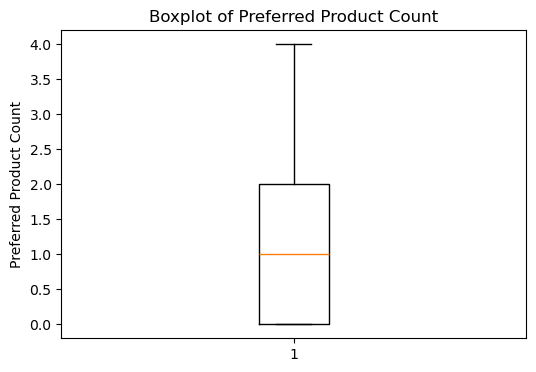

In [30]:
plt.figure(figsize=(6, 4))

plt.boxplot(df["Preferred_Product_Count"].dropna())

plt.title("Boxplot of Preferred Product Count")
plt.ylabel("Preferred Product Count")

plt.show()

# Logistic Regression

In [31]:
logistic_df = df[
    [
        "Territory",
        "Meeting_Location",
        "Preferred_Product_Count",
        "Purchase_Stage_Score"
    ]
].dropna().copy()

logistic_df.head()

,Territory,Meeting_Location,Preferred_Product_Count,Purchase_Stage_Score
0,Kalapara,Dakshin Debpur,0.0,1.0
2,Kalapara,Dakshin Debpur,1.0,2.0
4,Kalapara,Dakshin Debpur,3.0,2.0
7,Kalapara,Dakshin Debpur,0.0,1.0
11,Kalapara,Dakshin Debpur,0.0,1.0


## Target Variable

In [32]:
logistic_df["Product_Purchase_Flag"] = (
    logistic_df["Purchase_Stage_Score"] == 2
).astype(int)

logistic_df[
    [
        "Purchase_Stage_Score",
        "Product_Purchase_Flag"
    ]
].head()

,Purchase_Stage_Score,Product_Purchase_Flag
0,1.0,0
2,2.0,1
4,2.0,1
7,1.0,0
11,1.0,0


In [33]:
logistic_df["Product_Purchase_Flag"].value_counts()

Product_Purchase_Flag
1    101
0     39
Name: count, dtype: int64

## Converting Text Columns to Numerical Data

In [34]:
X = pd.get_dummies(
    logistic_df[
        [
            "Territory",
            "Meeting_Location",
            "Preferred_Product_Count"
        ]
    ],
    columns=[
        "Territory",
        "Meeting_Location"
    ],
    drop_first=True,
    dtype=int
)

X.head()

,Preferred_Product_Count,Territory_Charfashon,Territory_Kalapara,Territory_Patuakhali,"Meeting_Location_Kalai Shoula, Bauphal","Meeting_Location_Mujibnagar, Charfashon",Meeting_Location_Porir Khal
0,0.0,0,1,0,0,0,0
2,1.0,0,1,0,0,0,0
4,3.0,0,1,0,0,0,0
7,0.0,0,1,0,0,0,0
11,0.0,0,1,0,0,0,0


## Separating the Target Variable

In [35]:
y = logistic_df["Product_Purchase_Flag"]

y.head()

0     0
2     1
4     1
7     0
11    0
Name: Product_Purchase_Flag, dtype: int64

## Splitting Data into Training and Testing Sets

In [37]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [40]:
X_train.shape, X_test.shape

((112, 7), (28, 7))

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

## Fold Cross-Validation

In [42]:
classification_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

classification_cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## Fold Cross-Validation for Logistic Regression

In [43]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_cv_scores = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=classification_cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)

pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": logistic_cv_scores["test_accuracy"],
    "Precision": logistic_cv_scores["test_precision"],
    "Recall": logistic_cv_scores["test_recall"],
    "F1 Score": logistic_cv_scores["test_f1"]
}).round(3)

,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.913,0.895,1.000,0.944
1,2,0.870,0.933,0.875,0.903
2,3,0.909,1.000,0.875,0.933
3,4,0.955,1.000,0.938,0.968
4,5,0.909,0.889,1.000,0.941


In [44]:
pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Mean CV Score": [
        logistic_cv_scores["test_accuracy"].mean(),
        logistic_cv_scores["test_precision"].mean(),
        logistic_cv_scores["test_recall"].mean(),
        logistic_cv_scores["test_f1"].mean()
    ],
    "Standard Deviation": [
        logistic_cv_scores["test_accuracy"].std(),
        logistic_cv_scores["test_precision"].std(),
        logistic_cv_scores["test_recall"].std(),
        logistic_cv_scores["test_f1"].std()
    ]
}).round(3)

,Metric,Mean CV Score,Standard Deviation
0,Accuracy,0.911,0.027
1,Precision,0.943,0.049
2,Recall,0.938,0.056
3,F1 Score,0.938,0.021


In [45]:
logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Predicting Product Purchase on Test Data

In [46]:
y_pred_logistic = logistic_model.predict(X_test)

y_pred_logistic

array([1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1])

## Evaluating Logistic Regression Performance

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Test Score": [
        accuracy_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_logistic)
    ]
}).round(3)

,Metric,Test Score
0,Accuracy,0.964
1,Precision,1.000
2,Recall,0.950
3,F1 Score,0.974


## Confusion Matrix for Logistic Regression

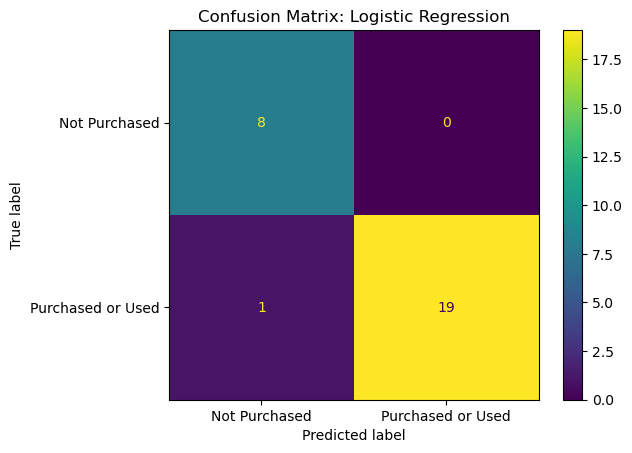

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

display_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=[
        "Not Purchased",
        "Purchased or Used"
    ]
)

display_logistic.plot()

plt.title("Confusion Matrix: Logistic Regression")
plt.show()

# Decision Tree

### Creating the Decision Tree Model

In [49]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Fold Cross-Validation for Decision Tree

In [50]:
tree_cv_scores = cross_validate(
    tree_model,
    X_train,
    y_train,
    cv=classification_cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)

pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": tree_cv_scores["test_accuracy"],
    "Precision": tree_cv_scores["test_precision"],
    "Recall": tree_cv_scores["test_recall"],
    "F1 Score": tree_cv_scores["test_f1"]
}).round(3)

,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.913,0.895,1.000,0.944
1,2,0.870,0.933,0.875,0.903
2,3,0.909,1.000,0.875,0.933
3,4,0.955,1.000,0.938,0.968
4,5,0.909,0.889,1.000,0.941


In [51]:
pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Mean CV Score": [
        tree_cv_scores["test_accuracy"].mean(),
        tree_cv_scores["test_precision"].mean(),
        tree_cv_scores["test_recall"].mean(),
        tree_cv_scores["test_f1"].mean()
    ],
    "Standard Deviation": [
        tree_cv_scores["test_accuracy"].std(),
        tree_cv_scores["test_precision"].std(),
        tree_cv_scores["test_recall"].std(),
        tree_cv_scores["test_f1"].std()
    ]
}).round(3)

,Metric,Mean CV Score,Standard Deviation
0,Accuracy,0.911,0.027
1,Precision,0.943,0.049
2,Recall,0.938,0.056
3,F1 Score,0.938,0.021


In [52]:
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Predicting Test Data with Decision Tree

In [53]:
y_pred_tree = tree_model.predict(X_test)

y_pred_tree

array([1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1])

## Evaluating Decision Tree Performance

In [54]:
pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Test Score": [
        accuracy_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_tree)
    ]
}).round(3)

,Metric,Test Score
0,Accuracy,0.964
1,Precision,1.000
2,Recall,0.950
3,F1 Score,0.974


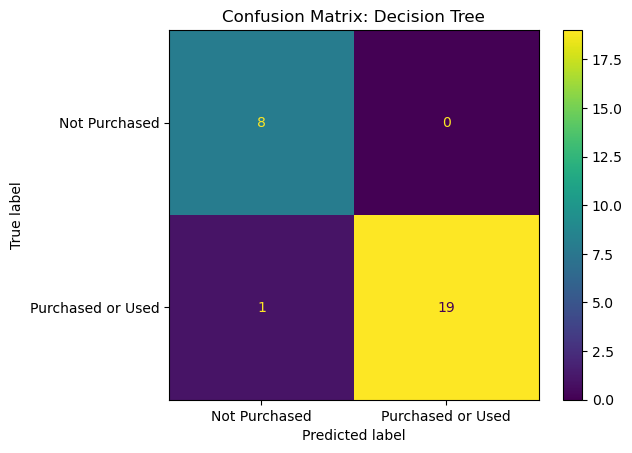

In [55]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

display_tree = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=[
        "Not Purchased",
        "Purchased or Used"
    ]
)

display_tree.plot()

plt.title("Confusion Matrix: Decision Tree")
plt.show()

In [56]:
np.array_equal(y_pred_logistic, y_pred_tree)

True

## Visualizing the Decision Tree

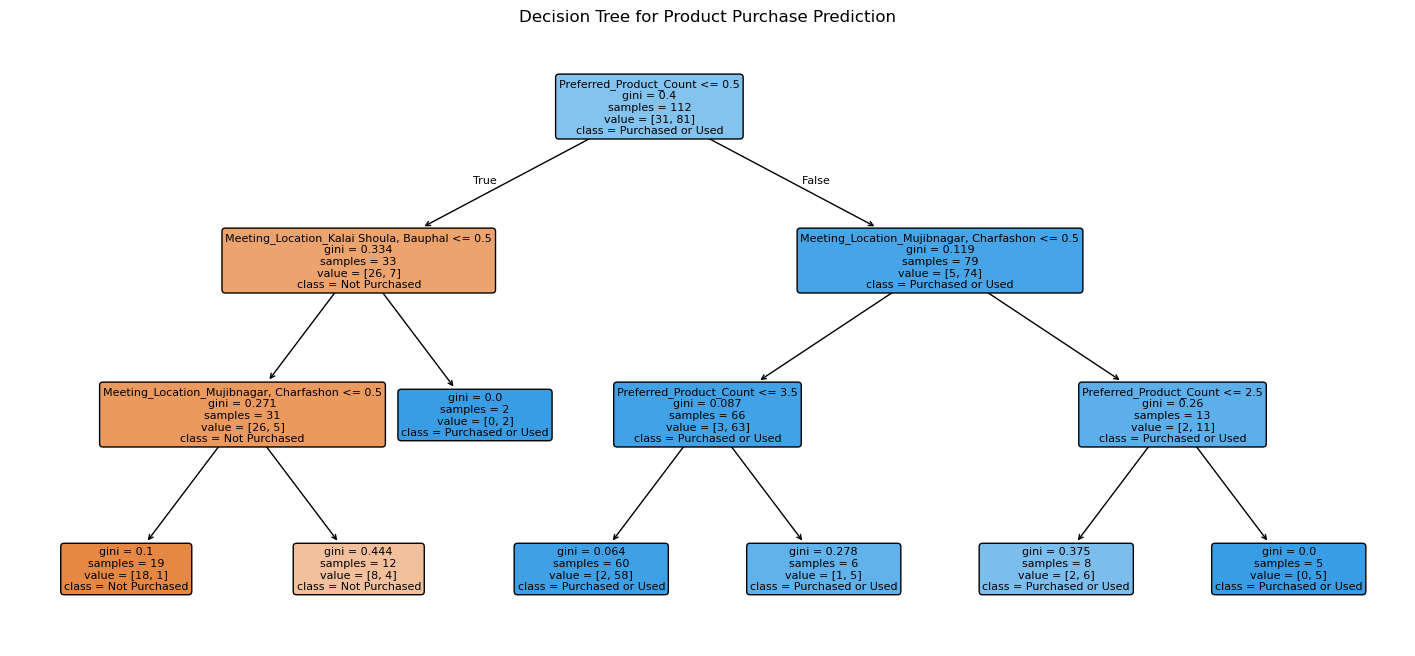

In [58]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Not Purchased", "Purchased or Used"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Product Purchase Prediction")
plt.show()

# Simple Linear Regression

## Creating Regression Dataset

In [59]:
reg_df = df[
    [
        "Preferred_Product_Count",
        "Purchased_Product_Count"
    ]
].dropna().copy()

reg_df.head()

,Preferred_Product_Count,Purchased_Product_Count
0,0.0,0.0
2,1.0,1.0
4,3.0,3.0
7,0.0,0.0
11,0.0,0.0


In [61]:
X_reg = reg_df[["Preferred_Product_Count"]]

y_reg = reg_df["Purchased_Product_Count"]

In [62]:
X_reg.head()

,Preferred_Product_Count
0,0.0
2,1.0
4,3.0
7,0.0
11,0.0


In [63]:
y_reg.head()

0     0.0
2     1.0
4     3.0
7     0.0
11    0.0
Name: Purchased_Product_Count, dtype: float64

## Splitting Regression Data into Training and Testing Sets

In [65]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [66]:
X_train_reg.shape, X_test_reg.shape

((120, 1), (31, 1))

## Fold Cross-Validation for Linear Regression

In [67]:
from sklearn.model_selection import KFold

regression_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

regression_cv

KFold(n_splits=5, random_state=42, shuffle=True)

##  Fold Cross-Validation for Linear Regression

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate

linear_model = LinearRegression()

linear_cv_scores = cross_validate(
    linear_model,
    X_train_reg,
    y_train_reg,
    cv=regression_cv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "mse": "neg_mean_squared_error"
    }
)

pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "R Squared": linear_cv_scores["test_r2"],
    "MAE": -linear_cv_scores["test_mae"],
    "MSE": -linear_cv_scores["test_mse"]
}).round(3)

,Fold,R Squared,MAE,MSE
0,1,0.560,0.408,0.476
1,2,0.874,0.302,0.160
2,3,0.883,0.295,0.151
3,4,0.459,0.446,0.563
4,5,0.445,0.323,0.551


In [69]:
pd.DataFrame({
    "Metric": [
        "R Squared",
        "Mean Absolute Error",
        "Mean Squared Error"
    ],
    "Mean CV Score": [
        linear_cv_scores["test_r2"].mean(),
        -linear_cv_scores["test_mae"].mean(),
        -linear_cv_scores["test_mse"].mean()
    ],
    "Standard Deviation": [
        linear_cv_scores["test_r2"].std(),
        linear_cv_scores["test_mae"].std(),
        linear_cv_scores["test_mse"].std()
    ]
}).round(3)

,Metric,Mean CV Score,Standard Deviation
0,R Squared,0.644,0.196
1,Mean Absolute Error,0.355,0.061
2,Mean Squared Error,0.380,0.186


In [71]:
linear_model.fit(X_train_reg, y_train_reg)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
y_pred_linear = linear_model.predict(X_test_reg)

y_pred_linear

array([0.10693176, 0.87733867, 0.87733867, 2.41815251, 0.10693176,
       0.87733867, 1.64774559, 1.64774559, 2.41815251, 0.87733867,
       2.41815251, 0.87733867, 0.87733867, 1.64774559, 0.87733867,
       0.10693176, 1.64774559, 0.10693176, 0.87733867, 0.10693176,
       0.87733867, 0.10693176, 0.10693176, 0.10693176, 0.10693176,
       2.41815251, 0.87733867, 0.10693176, 0.10693176, 0.87733867,
       1.64774559])

## Evaluating Linear Regression Performance

In [76]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.DataFrame({
    "Metric": [
        "R Squared",
        "Mean Absolute Error",
        "Mean Squared Error"
    ],
    "Test Score": [
        r2_score(y_test_reg, y_pred_linear),
        mean_absolute_error(y_test_reg, y_pred_linear),
        mean_squared_error(y_test_reg, y_pred_linear)
    ]
}).round(3)

,Metric,Test Score
0,R Squared,0.838
1,Mean Absolute Error,0.265
2,Mean Squared Error,0.151


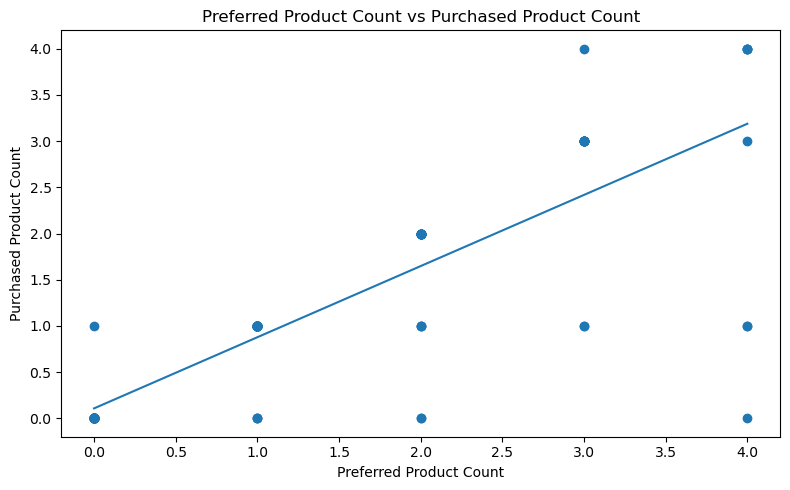

In [77]:
x_line = np.linspace(
    reg_df["Preferred_Product_Count"].min(),
    reg_df["Preferred_Product_Count"].max(),
    50
)

y_line = linear_model.predict(
    pd.DataFrame({
        "Preferred_Product_Count": x_line
    })
)

plt.figure(figsize=(8, 5))

plt.scatter(
    reg_df["Preferred_Product_Count"],
    reg_df["Purchased_Product_Count"]
)

plt.plot(
    x_line,
    y_line
)

plt.title("Preferred Product Count vs Purchased Product Count")
plt.xlabel("Preferred Product Count")
plt.ylabel("Purchased Product Count")
plt.tight_layout()
plt.show()

## Comparing Logistic Regression and Decision Tree

In [78]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "CV Accuracy": [
        logistic_cv_scores["test_accuracy"].mean(),
        tree_cv_scores["test_accuracy"].mean()
    ],
    "CV F1 Score": [
        logistic_cv_scores["test_f1"].mean(),
        tree_cv_scores["test_f1"].mean()
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Test F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree)
    ]
})

model_comparison.round(3)

,Model,CV Accuracy,CV F1 Score,Test Accuracy,Test F1 Score
0,Logistic Regression,0.911,0.938,0.964,0.974
1,Decision Tree,0.911,0.938,0.964,0.974
